# System Overhead Figures — EWL vs SFT

Generates three individual plots in `plots/`:
- `fig_system_step_time.pdf` — step time per epoch (line chart)
- `fig_system_throughput.pdf` — training throughput bar chart
- `fig_system_vram.pdf` — peak VRAM bar chart

**Data source:** `outputs/vision/all_datasets/{aircraft,cub200,stanford_dogs}/{baseline,ewl}_s{11,22,33}/results_*.json`

In [3]:
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

RESULTS_DIR = Path("../outputs/vision/all_datasets")
OUT_DIR = Path("plots")
OUT_DIR.mkdir(exist_ok=True)

In [4]:
# ── Load per-epoch timing data ────────────────────────────────────────────────
# Collect step_time_ms, throughput, vram per condition across all datasets/seeds.
# Also keep the full epoch-by-epoch trace for Aircraft seed 11 (panel a).

DATASETS = ["aircraft", "cub200", "stanford_dogs"]
COND_MAP  = {"baseline": "LoRA", "ewl": "EWL"}

# Aggregated across all datasets and seeds (for bar panels)
agg = {label: {"step": [], "thru": [], "vram": []} for label in COND_MAP.values()}

# Per-epoch trace: Aircraft, seed 11 only (for line panel)
trace = {}  # label -> list of step_time_ms per epoch

for dataset in DATASETS:
    for folder_prefix, label in COND_MAP.items():
        for seed in [11, 22, 33]:
            pattern = str(RESULTS_DIR / dataset / f"{folder_prefix}_s{seed}" / "results_*.json")
            files = sorted(glob.glob(pattern))
            if not files:
                continue
            d = json.load(open(files[-1]))
            h = d["history"]

            times = [e["step_time_ms"]              for e in h]
            thru  = [e["throughput_samples_per_sec"] for e in h]
            vram  = [e["peak_vram_gb"]               for e in h]

            # Skip epoch 1 for the aggregate stats (it inflates slightly due to init)
            agg[label]["step"] += times[1:]
            agg[label]["thru"] += thru[1:]
            agg[label]["vram"] += vram[1:]

            # Keep Aircraft seed-11 trace (all epochs, including epoch 1) for line plot
            if dataset == "aircraft" and seed == 11:
                trace[label] = {"times": times, "thru": thru}

print("Aggregated epochs per condition:")
for lbl, v in agg.items():
    print(f"  {lbl}: n={len(v['step'])}  "
          f"step={np.median(v['step']):.1f}ms  "
          f"thru={np.median(v['thru']):.0f} samp/s  "
          f"vram={np.median(v['vram']):.3f} GB")

print("\nAircraft s11 trace lengths:")
for lbl, v in trace.items():
    print(f"  {lbl}: {len(v['times'])} epochs, "
          f"epoch1={v['times'][0]:.1f}ms, median(2+)={np.median(v['times'][1:]):.1f}ms")

Aggregated epochs per condition:
  LoRA: n=81  step=45.0ms  thru=1422 samp/s  vram=9.456 GB
  EWL: n=81  step=268.5ms  thru=238 samp/s  vram=9.456 GB

Aircraft s11 trace lengths:
  LoRA: 10 epochs, epoch1=56.4ms, median(2+)=44.9ms
  EWL: 10 epochs, epoch1=277.9ms, median(2+)=264.7ms


Saved plots/fig_system_step_time.pdf


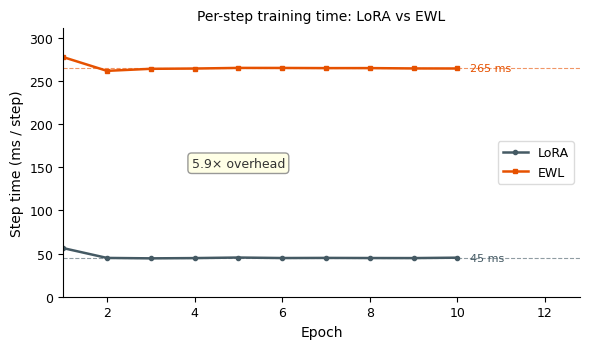

In [5]:
C_sft = "#455A64"   # blue-grey
C_ewl = "#E65100"   # deep orange

epochs    = list(range(1, len(trace["LoRA"]["times"]) + 1))
sft_med   = np.median(trace["LoRA"]["times"][1:])
ewl_med   = np.median(trace["EWL"]["times"][1:])
ratio     = ewl_med / sft_med
labels    = ["LoRA", "EWL"]
colors    = [C_sft, C_ewl]
thru_vals = [np.median(agg["LoRA"]["thru"]), np.median(agg["EWL"]["thru"])]
vram_vals = [np.median(agg["LoRA"]["vram"]), np.median(agg["EWL"]["vram"])]

def save(fig, name):
    path = OUT_DIR / name
    fig.savefig(str(path) + ".pdf", dpi=300, bbox_inches="tight")
    print(f"Saved {path}.pdf")

# ── Figure 1: Step time per epoch ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3.6))
fig.patch.set_facecolor("white")

ax.plot(epochs, trace["LoRA"]["times"], color=C_sft, lw=1.8, marker="o", ms=3, label="LoRA")
ax.plot(epochs, trace["EWL"]["times"], color=C_ewl, lw=1.8, marker="s", ms=3, label="EWL")
ax.axhline(sft_med, color=C_sft, lw=0.8, ls="--", alpha=0.6)
ax.axhline(ewl_med, color=C_ewl, lw=0.8, ls="--", alpha=0.6)
ax.text(epochs[-1] + 0.3, sft_med, f"{sft_med:.0f} ms", va="center", ha="left", fontsize=8, color=C_sft)
ax.text(epochs[-1] + 0.3, ewl_med, f"{ewl_med:.0f} ms", va="center", ha="left", fontsize=8, color=C_ewl)
ax.annotate(
    f"{ratio:.1f}× overhead",
    xy=(len(epochs) // 2, (sft_med + ewl_med) / 2),
    fontsize=9, color="#333333", ha="center", va="center",
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="grey", alpha=0.8)
)
ax.set_xlabel("Epoch", fontsize=10)
ax.set_ylabel("Step time (ms / step)", fontsize=10)
ax.set_title("Per-step training time: LoRA vs EWL", fontsize=10, pad=6)
ax.legend(fontsize=9, framealpha=0.7)
ax.set_xlim(1, epochs[-1] + 2.8)
ax.set_ylim(0, max(trace["EWL"]["times"]) * 1.12)
ax.tick_params(labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save(fig, "fig_system_step_time")
plt.show()

Saved plots/fig_system_throughput.pdf


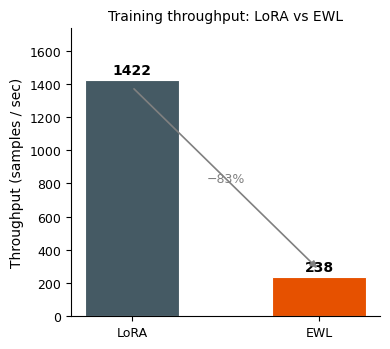

In [6]:
# ── Figure 2: Throughput bar ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 3.6))
fig.patch.set_facecolor("white")

bars = ax.bar(labels, thru_vals, color=colors, width=0.5, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, thru_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 18,
            f"{val:.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

drop_pct = (1 - thru_vals[1] / thru_vals[0]) * 100
ax.annotate("", xy=(1, thru_vals[1] + 40), xytext=(0, thru_vals[0] - 40),
            arrowprops=dict(arrowstyle="-|>", color="grey", lw=1.2))
ax.text(0.5, (thru_vals[0] + thru_vals[1]) / 2,
        f"−{drop_pct:.0f}%", ha="center", va="center", fontsize=9, color="grey")

ax.set_ylabel("Throughput (samples / sec)", fontsize=10)
ax.set_title("Training throughput: LoRA vs EWL", fontsize=10, pad=6)
ax.set_ylim(0, max(thru_vals) * 1.22)
ax.tick_params(labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save(fig, "fig_system_throughput")
plt.show()

Saved plots/fig_system_vram.pdf


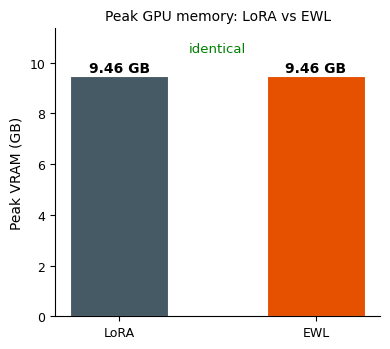

In [7]:
# ── Figure 3: VRAM bar ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 3.6))
fig.patch.set_facecolor("white")

bars2 = ax.bar(labels, vram_vals, color=colors, width=0.5, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars2, vram_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.04,
            f"{val:.2f} GB", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.text(0.5, max(vram_vals) * 1.09, "identical",
        ha="center", va="bottom", fontsize=9.5, color="green",
        transform=ax.transData)

ax.set_ylabel("Peak VRAM (GB)", fontsize=10)
ax.set_title("Peak GPU memory: LoRA vs EWL", fontsize=10, pad=6)
ax.set_ylim(0, max(vram_vals) * 1.2)
ax.tick_params(labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save(fig, "fig_system_vram")
plt.show()